In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy import signal
from scipy.signal import hilbert
import umap

sys.path.insert(0, r"/Users/novak/Documents/UTSW/erfan/deeplagfield/StocasticDiffEq_Simulation")

from NeuralFieldManifold.models import AR
from NeuralFieldManifold.embedders import embed
from NeuralFieldManifold.pub_utils import set_pub_style, prettify
set_pub_style()

/Users/novak/miniforge3/envs/armodeling/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
signal_path = r"/Users/novak/Documents/UTSW/erfan/deeplagfield/eeg_signal_sec3.npy"
time_path   = r"/Users/novak/Documents/UTSW/erfan/deeplagfield/eeg_time_sec3.npy"
label_path  = r"/Users/novak/Documents/UTSW/erfan/deeplagfield/state_sec3.npy"

eeg = np.load(signal_path)
time = np.load(time_path)
labels = np.load(label_path)

fs = 400

print(f"EEG shape: {eeg.shape}, fs: {fs:.1f} Hz")
print(f"Time shape: {time.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Unique labels: {np.unique(labels)}")
print(f"Duration: {len(eeg)/fs:.1f} sec")

EEG shape: (1440000,), fs: 400.0 Hz
Time shape: (1440000,)
Labels shape: (1800,)
Unique labels: [0 1 2]
Duration: 3600.0 sec


In [3]:
def load_eeg_data(time_path, signal_path):
    """Load EEG data from numpy files."""
    time = np.load(time_path)
    signal_data = np.load(signal_path)
    fs = 1 / np.mean(np.diff(time))
    return time, signal_data, fs

def bandpass_filter(x, Fs, low, high, order=4):
    wn = [low/(Fs/2), high/(Fs/2)]
    sos = signal.butter(order, wn, btype='bandpass', output='sos')
    return signal.sosfiltfilt(sos, x)

def envelope_normalize(x, fs, fband=(15, 30), env_lp_hz=5.0, eps=1e-6):
    b, a = signal.butter(4, np.array(fband)/(fs/2), btype='bandpass')
    x_bp = signal.filtfilt(b, a, x)
    z = hilbert(x_bp)
    A = np.abs(z)
    if env_lp_hz is not None:
        b_lp, a_lp = signal.butter(2, env_lp_hz/(fs/2), btype='low')
        A = signal.filtfilt(b_lp, a_lp, A)
    x_flat = x_bp / (A + eps)
    x_flat *= np.median(A)
    return x_flat, x_bp, A

def process_eeg_signal(raw_signal, Fs, 
                       notch_freq=60, notch_Q=30,
                       bandpass_low=0.5, bandpass_high=40,
                       fband=(1, 40), env_lp_hz=3.0):
    """Process EEG signal with notch filter, bandpass, and envelope normalization."""
    filtered = signal.filtfilt(*signal.iirnotch(notch_freq, notch_Q, Fs), raw_signal)
    x = np.asarray(filtered).ravel()
    xs_raw = bandpass_filter(x, Fs, low=bandpass_low, high=bandpass_high)
    xs, _, _ = envelope_normalize(xs_raw, Fs, fband=fband, env_lp_hz=env_lp_hz)
    return xs, xs_raw

In [4]:
preprocessed, xs_raw = process_eeg_signal(eeg, fs)

win_samples = int(2 * fs)
n_windows = len(labels)

eeg_windows = preprocessed.reshape(n_windows, win_samples)

# Band power features (baseline decoder)
bands = {
    'delta': (0.5, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta':  (13, 30),
}

band_power = np.zeros((n_windows, len(bands)))

for i in range(n_windows):
    freqs, psd = welch(eeg_windows[i], fs=fs, nperseg=min(512, win_samples), noverlap=256)
    for j, (band_name, (flo, fhi)) in enumerate(bands.items()):
        idx = (freqs >= flo) & (freqs <= fhi)
        band_power[i, j] = np.trapezoid(psd[idx], freqs[idx])
band_power_log = np.log10(band_power + 1e-12)

In [5]:
tau = 1
dim = 3

feature_list = []

for i in range(n_windows):
    X3 = embed(eeg_windows[i], dim, tau)
    
    mu = X3.mean(axis=0)          # 3 features
    sd = X3.std(axis=0)           # 3 features  
    
    cov = np.cov(X3.T)
    triu_idx = np.triu_indices(dim)
    cov_feat = cov[triu_idx]      # 6 features
    
    feature_list.append(np.concatenate([mu, sd, cov_feat]))

embed_features_rich = np.array(feature_list)

In [6]:
from sklearn.utils import resample
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Undersample to balance classes
np.random.seed(42)
min_count = min(np.sum(labels == 0), np.sum(labels == 1), np.sum(labels == 2))
print(f"Balancing to {min_count} samples per class")

idx_balanced = []
for state in [0, 1, 2]:
    state_idx = np.where(labels == state)[0]
    chosen = resample(state_idx, n_samples=min_count, replace=False, random_state=42)
    idx_balanced.extend(chosen)

idx_balanced = np.array(idx_balanced)
np.random.shuffle(idx_balanced)

labels_bal = labels[idx_balanced]
band_bal = band_power_log[idx_balanced]
embed_bal = embed_features_rich[idx_balanced]

print(f"Balanced dataset: {len(labels_bal)} samples")
for v in [0, 1, 2]:
    print(f"  Class {v}: {np.sum(labels_bal == v)}")

# KNN classifier (replacing LDA)
knn = KNeighborsClassifier(n_neighbors=5)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pred_band_bal = cross_val_predict(knn, band_bal, labels_bal, cv=cv)
pred_embed_bal = cross_val_predict(knn, embed_bal, labels_bal, cv=cv)

acc_band_bal = accuracy_score(labels_bal, pred_band_bal)
acc_embed_bal = accuracy_score(labels_bal, pred_embed_bal)

print(f"\nBand power:    acc={acc_band_bal:.3f}")
print(f"Lag embedding: acc={acc_embed_bal:.3f}")
print(f"\nBand power report:")
print(classification_report(labels_bal, pred_band_bal, target_names=['Wake','NREM','REM']))
print(f"Lag embedding report:")
print(classification_report(labels_bal, pred_embed_bal, target_names=['Wake','NREM','REM']))

Balancing to 109 samples per class
Balanced dataset: 327 samples
  Class 0: 109
  Class 1: 109
  Class 2: 109

Band power:    acc=0.584
Lag embedding: acc=0.673

Band power report:
              precision    recall  f1-score   support

        Wake       0.55      0.64      0.59       109
        NREM       0.65      0.71      0.68       109
         REM       0.55      0.40      0.47       109

    accuracy                           0.58       327
   macro avg       0.58      0.58      0.58       327
weighted avg       0.58      0.58      0.58       327

Lag embedding report:
              precision    recall  f1-score   support

        Wake       0.61      0.57      0.59       109
        NREM       0.80      0.91      0.85       109
         REM       0.57      0.54      0.56       109

    accuracy                           0.67       327
   macro avg       0.66      0.67      0.67       327
weighted avg       0.66      0.67      0.67       327



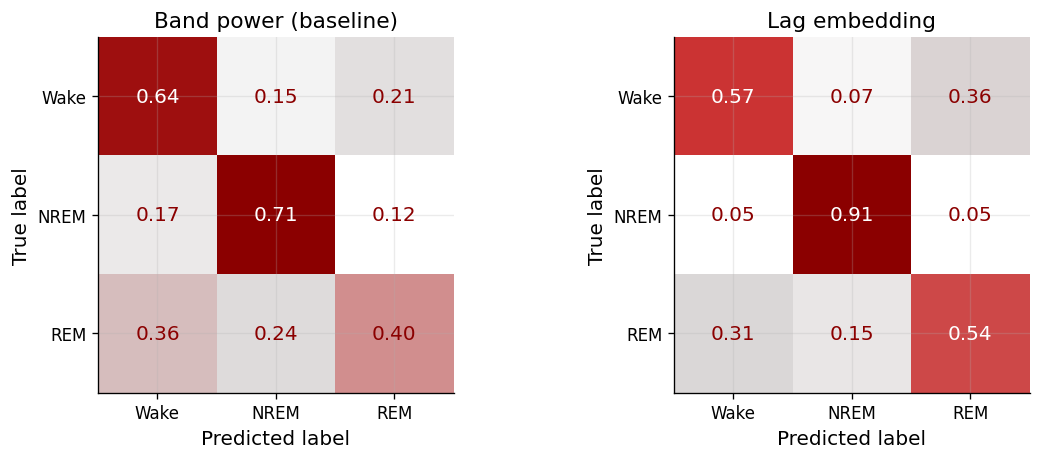

/Users/novak/miniforge3/envs/armodeling/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


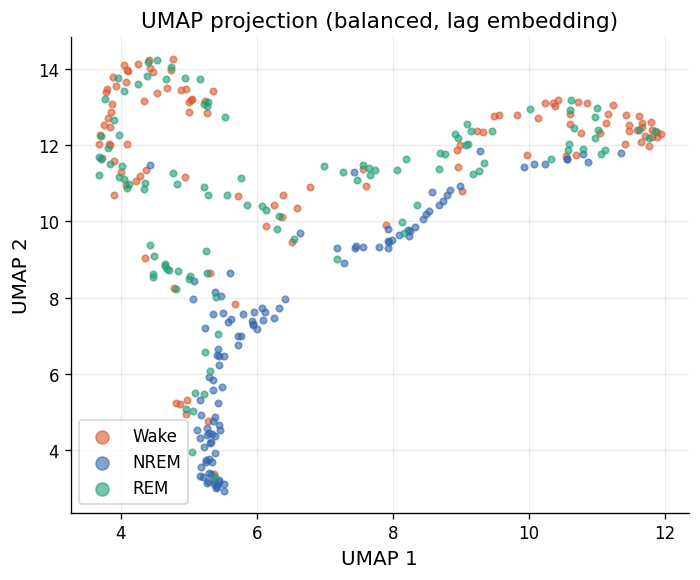

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay
from matplotlib import colors as mcolors

state_names = ['Wake', 'NREM', 'REM']
colors = {0: '#D85A30', 1: '#3266ad', 2: '#1D9E75'}

cmap = mcolors.LinearSegmentedColormap.from_list(
    "white_majority_darkred",
    [
        (0.0, "#ffffff"),
        (0.35, "#aca3a36c"),
        (0.60, "#c10404cf"),
        (1.0, "#8b0000ff")
    ]
)

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_band = confusion_matrix(labels_bal, pred_band_bal, normalize='true')
ConfusionMatrixDisplay(cm_band, display_labels=state_names).plot(ax=axes[0], cmap=cmap, values_format='.2f', colorbar=False)
axes[0].set_title('Band power (baseline)')

cm_embed = confusion_matrix(labels_bal, pred_embed_bal, normalize='true')
ConfusionMatrixDisplay(cm_embed, display_labels=state_names).plot(ax=axes[1], cmap=cmap, values_format='.2f', colorbar=False)
axes[1].set_title('Lag embedding')

plt.tight_layout()
plt.show()

# UMAP projection on balanced data (replacing LDA)
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(embed_bal)

fig, ax = plt.subplots(figsize=(6, 5))
for label, name in enumerate(state_names):
    mask = labels_bal == label
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
               c=colors[label], label=name, s=15, alpha=0.6)

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP projection (balanced, lag embedding)')
ax.legend(markerscale=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

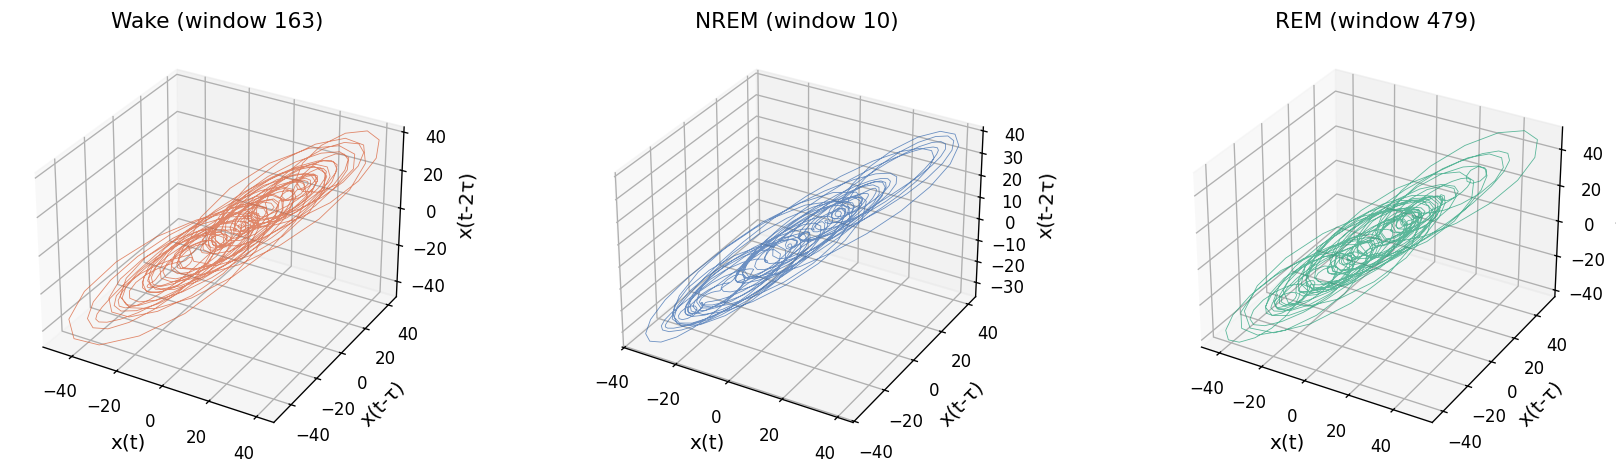

In [8]:
# Pick one example window from each state
idx_wake = np.where(labels == 0)[0][10]   # 10th Wake window
idx_nrem = np.where(labels == 1)[0][10]   # 10th NREM window
idx_rem  = np.where(labels == 2)[0][5]    # 5th REM window

fig = plt.figure(figsize=(15, 4))

for i, (idx, name, color) in enumerate([
    (idx_wake, 'Wake', '#D85A30'),
    (idx_nrem, 'NREM', '#3266ad'),
    (idx_rem,  'REM',  '#1D9E75')
]):
    X3 = embed(eeg_windows[idx], dim, tau)
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    ax.plot(X3[:, 0], X3[:, 1], X3[:, 2], lw=0.5, alpha=0.7, color=color)
    ax.set_title(f'{name} (window {idx})')
    ax.set_xlabel('x(t)')
    ax.set_ylabel('x(t-τ)')
    ax.set_zlabel('x(t-2τ)')

plt.tight_layout()
plt.show()